In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# sTART

In [2]:
df = pd.read_csv('train.csv')
df.head()

,id,num_1,num_2,num_3,num_4,num_5,num_6,num_7,num_8,num_9,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7,target
0,0,68,15136,148531,491,80,4,14.98,12,0.55,Bachelor's,Self-employed,Divorced,No,No,Auto,Yes,1
1,1,66,148756,40664,825,16,4,11.32,48,0.25,Bachelor's,Unemployed,Single,Yes,No,Other,No,0
2,2,61,42190,138134,378,5,1,20.50,48,0.79,Bachelor's,Unemployed,Married,Yes,No,Education,Yes,0
3,3,21,89531,33212,558,72,1,14.61,12,0.48,High School,Part-time,Divorced,No,Yes,Auto,Yes,1
4,4,60,36068,72656,659,25,3,7.84,60,0.82,PhD,Part-time,Single,No,Yes,Business,No,0


In [3]:
df.rename({
    'num_1': 'umur',
    'num_2': 'pendapatan',
    'num_3': 'pinjaman',
    'num_4': 'skor_kredit',
    'num_5': 'bulan_bekerja',
    'num_6': 'jumlah_akun_kredit_yang_aktif',
    'num_7': 'interest',
    'num_8': 'bulan_pinjaman',
    'num_9': 'ratio_debt_to_income',
    'cat_1': 'level_edukasi',
    'cat_2': 'jenis_pekerjaan',
    'cat_3': 'status_menikah',
    'cat_4': 'ada_mortgage',
    'cat_5': 'punya_tanggungan',
    'cat_6': 'tujuan_loan',
    'cat_7': 'ada_cosigner',
    'target': 'loan_default_status'
}, axis=1, inplace=True)

df.head()

,id,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,level_edukasi,jenis_pekerjaan,status_menikah,ada_mortgage,punya_tanggungan,tujuan_loan,ada_cosigner,loan_default_status
0,0,68,15136,148531,491,80,4,14.98,12,0.55,Bachelor's,Self-employed,Divorced,No,No,Auto,Yes,1
1,1,66,148756,40664,825,16,4,11.32,48,0.25,Bachelor's,Unemployed,Single,Yes,No,Other,No,0
2,2,61,42190,138134,378,5,1,20.50,48,0.79,Bachelor's,Unemployed,Married,Yes,No,Education,Yes,0
3,3,21,89531,33212,558,72,1,14.61,12,0.48,High School,Part-time,Divorced,No,Yes,Auto,Yes,1
4,4,60,36068,72656,659,25,3,7.84,60,0.82,PhD,Part-time,Single,No,Yes,Business,No,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             38000 non-null  int64  
 1   umur                           38000 non-null  int64  
 2   pendapatan                     38000 non-null  int64  
 3   pinjaman                       38000 non-null  int64  
 4   skor_kredit                    38000 non-null  int64  
 5   bulan_bekerja                  38000 non-null  int64  
 6   jumlah_akun_kredit_yang_aktif  38000 non-null  int64  
 7   interest                       38000 non-null  float64
 8   bulan_pinjaman                 38000 non-null  int64  
 9   ratio_debt_to_income           38000 non-null  float64
 10  level_edukasi                  38000 non-null  object 
 11  jenis_pekerjaan                38000 non-null  object 
 12  status_menikah                 38000 non-null 

In [20]:
df.isna().sum().sort_values(ascending=False)

id                               0
level_edukasi                    0
loan_default_status              0
ada_cosigner                     0
tujuan_loan                      0
punya_tanggungan                 0
ada_mortgage                     0
status_menikah                   0
jenis_pekerjaan                  0
ratio_debt_to_income             0
umur                             0
bulan_pinjaman                   0
interest                         0
jumlah_akun_kredit_yang_aktif    0
bulan_bekerja                    0
skor_kredit                      0
pinjaman                         0
pendapatan                       0
age_bin                          0
dtype: int64

In [15]:
df.describe()

,id,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,loan_default_status
count,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000
mean,18999.500000,41.350184,79257.395316,133175.401553,570.365842,56.736921,2.534105,14.246398,36.017684,0.504017,0.394737
std,10969.799451,15.024800,39854.914883,70800.991665,159.348195,34.831082,1.120539,6.658927,16.941723,0.229774,0.488801
min,0.000000,18.000000,15006.000000,4999.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,9499.750000,28.000000,43717.750000,72613.750000,432.000000,26.000000,2.000000,8.570000,24.000000,0.310000,0.000000
50%,18999.500000,40.000000,78135.500000,135945.500000,568.000000,55.000000,3.000000,14.620000,36.000000,0.510000,0.000000
75%,28499.250000,54.000000,113869.250000,195121.250000,708.000000,87.000000,4.000000,20.150000,48.000000,0.700000,1.000000
max,37999.000000,69.000000,149995.000000,249994.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [4]:
df = df.drop(columns=['id'])

# Check Unique Value

## Number

In [17]:
for col in df.columns:
    print(f'{col}: {df[col].unique()}')
    print('')

umur: [68 66 61 21 60 65 45 19 64 25 22 26 41 33 51 59 31 38 62 48 20 57 52 34
 54 40 23 43 47 46 24 29 18 50 27 55 49 28 53 35 56 63 44 67 32 30 58 42
 37 39 69 36]

pendapatan: [ 15136 148756  42190 ...  27778  71537  40727]

pinjaman: [148531  40664 138134 ...  56346 121275 119136]

skor_kredit: [491 825 378 558 659 461 758 310 356 354 505 744 464 560 742 690 676 363
 691 761 612 438 819 480 750 639 440 495 803 821 630 637 353 590 610 679
 382 390 843 704 773 543 762 508 524 636 535 364 810 338 688 381 720 317
 436 414 798 749 731 692 793 752 760 826 487 583 589 588 694 304 319 847
 848 568 602 582 323 434 732 373 447 678 812 407 388 501 647 541 503 701
 467 451 514 565 601 827 510 301 526 797 706 840 435 831 442 681 424 532
 484 564 765 437 655 375 822 828 623 661 406 806 432 552 557 727 499 698
 622 515 811 405 536 393 470 747 753 674 492 613 401 566 569 799 650 680
 350 599 476 844 600 818 383 423 404 707 547 528 745 741 307 563 665 302
 516 769 626 735 783 593 755 452 632 348 71

## Categorical

In [18]:
for col in df.select_dtypes(include='object'):
    print(f'{col}: {df[col].unique()}')
    print('')

level_edukasi: ["Bachelor's" 'High School' 'PhD' "Master's"]

jenis_pekerjaan: ['Self-employed' 'Unemployed' 'Part-time' 'Full-time']

status_menikah: ['Divorced' 'Single' 'Married']

ada_mortgage: ['No' 'Yes']

punya_tanggungan: ['No' 'Yes']

tujuan_loan: ['Auto' 'Other' 'Education' 'Business' 'Home']

ada_cosigner: ['Yes' 'No']



# Encoder

In [5]:
df['level_edukasi'] = df['level_edukasi'].map({"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3})
df['jenis_pekerjaan'] = df['jenis_pekerjaan'].map({"Unemployed": 0, "Self-employed": 1, "Part-time": 2, "Full-time": 3})
df['status_menikah'] = df['status_menikah'].map({"Single": 0, "Divorced": 1, "Married": 2})
df['ada_mortgage'] = df['ada_mortgage'].map({"No": 0, "Yes": 1})
df['punya_tanggungan'] = df['punya_tanggungan'].map({"No": 0, "Yes": 1})
df['tujuan_loan'] = df['tujuan_loan'].map({"Other": 0, "Education": 1, "Auto": 2, "Home": 3, "Business": 4})
df['ada_cosigner'] = df['ada_cosigner'].map({"No": 0, "Yes": 1})

df.head()

,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,level_edukasi,jenis_pekerjaan,status_menikah,ada_mortgage,punya_tanggungan,tujuan_loan,ada_cosigner,loan_default_status
0,68,15136,148531,491,80,4,14.98,12,0.55,1,1,1,0,0,2,1,1
1,66,148756,40664,825,16,4,11.32,48,0.25,1,0,0,1,0,0,0,0
2,61,42190,138134,378,5,1,20.50,48,0.79,1,0,2,1,0,1,1,0
3,21,89531,33212,558,72,1,14.61,12,0.48,0,2,1,0,1,2,1,1
4,60,36068,72656,659,25,3,7.84,60,0.82,3,2,0,0,1,4,0,0


# Model

In [6]:
from imblearn.under_sampling import RandomUnderSampler
X = df.drop(columns='loan_default_status')
y = df['loan_default_status']
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

In [37]:
y_resampled.value_counts()

loan_default_status
0    15000
1    15000
Name: count, dtype: int64

In [7]:
# X = df.drop(columns='loan_default_status')[['umur','pendapatan','pinjaman','bulan_kerja','interest']]
# y = df['loan_default_status']
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# cat_col = ['level_edukasi', 'jenis_pekerjaan', 'status_menikah', 'ada_mortgage', 'punya_tanggungan', 'tujuan_loan', 'ada_cosigner']
# num_col = ['umur', 'pendapatan', 'pinjaman', 'bulan_bekerja', 'interest']

# Baseline KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


y_pred_train= knn.predict(X_train)
y_pred_test= knn.predict(X_test)

In [ ]:
y_prob = knn.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.5719772595117684


# Baseline Logistic

In [ ]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)

model_lr.fit(X_train, y_train)

y_pred_train= model_lr.predict(X_train)
y_pred_test= model_lr.predict(X_test)

In [31]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))

Classification Report Train:
              precision    recall  f1-score   support

           0       0.50      0.00      0.01       390
           1       0.97      1.00      0.98     12010

    accuracy                           0.97     12400
   macro avg       0.73      0.50      0.49     12400
weighted avg       0.95      0.97      0.95     12400



In [58]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Test:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       110
           1       0.96      1.00      0.98      2990

    accuracy                           0.96      3100
   macro avg       0.48      0.50      0.49      3100
weighted avg       0.93      0.96      0.95      3100



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


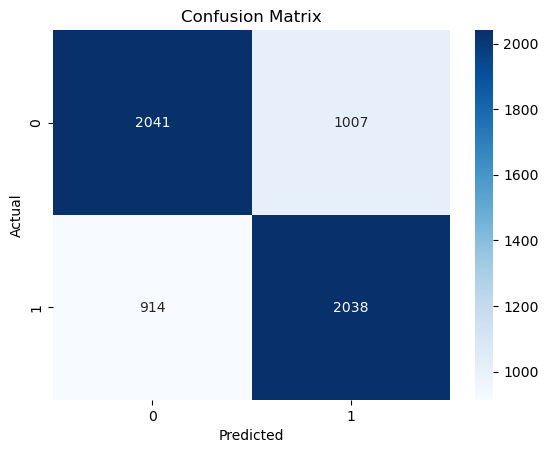

In [157]:
cm= confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [155]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(model_lr, X_train_preprocessed, y_train, scoring=scoring, cv=3)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.69   0.6815 0.682 ]
Precision scores: [0.68851252 0.68105575 0.67574021]
Recall scores: [0.69845618 0.6875     0.70468127]
Mean Accuracy: 0.6845
Mean Precision: 0.6817694919811851
Mean Recall: 0.6968791500664011


In [156]:
y_prob = model_lr.predict_proba(X_test_preprocessed)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.7449595985461167


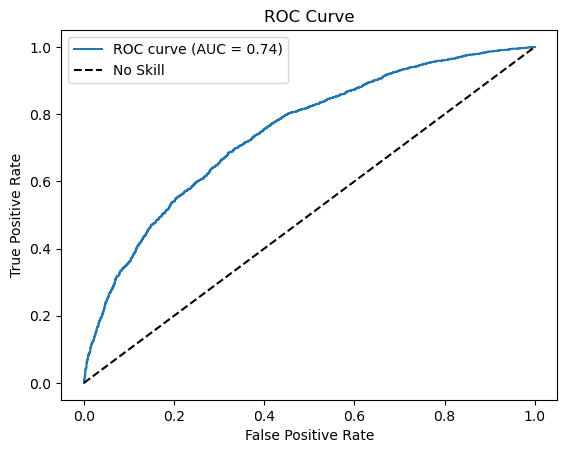

In [74]:
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Boosting

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:


model_gb = GradientBoostingClassifier(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=3)

model_gb.fit(X_train, y_train)

y_pred_train = model_gb.predict(X_train)
y_pred_test  = model_gb.predict(X_test)

In [18]:
y_prob = model_gb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.7494158504577172


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':   [190, 200, 210],
    'max_depth':      [1, 2],
}

grid_search = GridSearchCV(
    estimator  = GradientBoostingClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'roc_auc',   # ganti sesuai metrik targetmu
    n_jobs     = -1,
    verbose    = 2
)

grid_search.fit(X_train, y_train)

print("Best Params :", grid_search.best_params_)
print("Best CV AUC :", grid_search.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params : {'max_depth': 2, 'n_estimators': 210}
Best CV AUC : 0.7545615471792498


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':   [170, 180 ,190],
    'max_depth':      [2, 3, 4],
}

grid_search = GridSearchCV(
    estimator  = GradientBoostingClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'roc_auc',   # ganti sesuai metrik targetmu
    n_jobs     = -1,
    verbose    = 2
)

grid_search.fit(X_train, y_train)

print("Best Params :", grid_search.best_params_)
print("Best CV AUC :", grid_search.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params : {'max_depth': 2, 'n_estimators': 170}
Best CV AUC : 0.754092494653832


In [11]:
test = pd.read_csv('secret_test_features.csv')
test.head()

,id,num_1,num_2,num_3,num_4,num_5,num_6,num_7,num_8,num_9,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7
0,0,46,76085,130717,744,36,3,16.08,60,0.82,Master's,Full-time,Married,Yes,Yes,Education,No
1,1,26,134215,190402,510,52,1,16.26,48,0.75,PhD,Self-employed,Single,No,Yes,Education,No
2,2,60,107244,89890,429,2,1,12.51,60,0.67,High School,Full-time,Married,No,No,Education,No
3,3,69,28829,132654,500,26,2,16.93,36,0.72,Master's,Self-employed,Married,Yes,No,Education,No
4,4,64,32757,93185,638,59,1,24.50,36,0.76,Master's,Full-time,Divorced,Yes,Yes,Home,No


In [12]:
test.rename({
    'num_1': 'umur',
    'num_2': 'pendapatan',
    'num_3': 'pinjaman',
    'num_4': 'skor_kredit',
    'num_5': 'bulan_bekerja',
    'num_6': 'jumlah_akun_kredit_yang_aktif',
    'num_7': 'interest',
    'num_8': 'bulan_pinjaman',
    'num_9': 'ratio_debt_to_income',
    'cat_1': 'level_edukasi',
    'cat_2': 'jenis_pekerjaan',
    'cat_3': 'status_menikah',
    'cat_4': 'ada_mortgage',
    'cat_5': 'punya_tanggungan',
    'cat_6': 'tujuan_loan',
    'cat_7': 'ada_cosigner',
    'target': 'loan_default_status'
}, axis=1, inplace=True)

test.head()

,id,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,level_edukasi,jenis_pekerjaan,status_menikah,ada_mortgage,punya_tanggungan,tujuan_loan,ada_cosigner
0,0,46,76085,130717,744,36,3,16.08,60,0.82,Master's,Full-time,Married,Yes,Yes,Education,No
1,1,26,134215,190402,510,52,1,16.26,48,0.75,PhD,Self-employed,Single,No,Yes,Education,No
2,2,60,107244,89890,429,2,1,12.51,60,0.67,High School,Full-time,Married,No,No,Education,No
3,3,69,28829,132654,500,26,2,16.93,36,0.72,Master's,Self-employed,Married,Yes,No,Education,No
4,4,64,32757,93185,638,59,1,24.50,36,0.76,Master's,Full-time,Divorced,Yes,Yes,Home,No


In [14]:
test['level_edukasi'] = test['level_edukasi'].map({"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3})
test['jenis_pekerjaan'] = test['jenis_pekerjaan'].map({"Unemployed": 0, "Self-employed": 1, "Part-time": 2, "Full-time": 3})
test['status_menikah'] = test['status_menikah'].map({"Single": 0, "Divorced": 1, "Married": 2})
test['ada_mortgage'] = test['ada_mortgage'].map({"No": 0, "Yes": 1})
test['punya_tanggungan'] = test['punya_tanggungan'].map({"No": 0, "Yes": 1})
test['tujuan_loan'] = test['tujuan_loan'].map({"Other": 0, "Education": 1, "Auto": 2, "Home": 3, "Business": 4})
test['ada_cosigner'] = test['ada_cosigner'].map({"No": 0, "Yes": 1})


In [23]:



# model_gb = GradientBoostingClassifier(max_depth =3, n_estimators= 150)

# # model_gb.fit(X_train, y_train)

y_pred = grid_search.predict(test.drop('id',axis=1))
y_prob = grid_search.predict_proba(test.drop('id',axis=1))[:,1]

In [ ]:
len(y_prob)

array([0.25844293, 0.28019734, 0.58867901, ..., 0.29444894, 0.75727269,
       0.51719361], shape=(6000,))

In [24]:


pd.DataFrame({
    "id": test['id'],
    "prediction": y_pred,
    "probability": y_prob, 
}).to_csv('nama_team_2.csv')

In [34]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'iterations':    [500, 550, 600],
    'learning_rate': [0.1, 0.01, 0.05],
}

grid_search_cat = GridSearchCV(
    estimator  = CatBoostClassifier(random_state=42, verbose=0),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 2
)

grid_search_cat.fit(X_train, y_train)

print("Best Params :", grid_search_cat.best_params_)
print("Best CV AUC :", grid_search_cat.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Params : {'iterations': 600, 'learning_rate': 0.01}
Best CV AUC : 0.7558866717469863


In [13]:
y_prob = model_xgb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.7491617298472852


# Decision Tree

In [19]:
model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

y_pred_train= model_dt.predict(X_train)
y_pred_test= model_dt.predict(X_test)


In [21]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))

Classification Report Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11952
           1       1.00      1.00      1.00     12048

    accuracy                           1.00     24000
   macro avg       1.00      1.00      1.00     24000
weighted avg       1.00      1.00      1.00     24000



In [22]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Test:
              precision    recall  f1-score   support

           0       0.59      0.58      0.58      3048
           1       0.57      0.58      0.57      2952

    accuracy                           0.58      6000
   macro avg       0.58      0.58      0.58      6000
weighted avg       0.58      0.58      0.58      6000



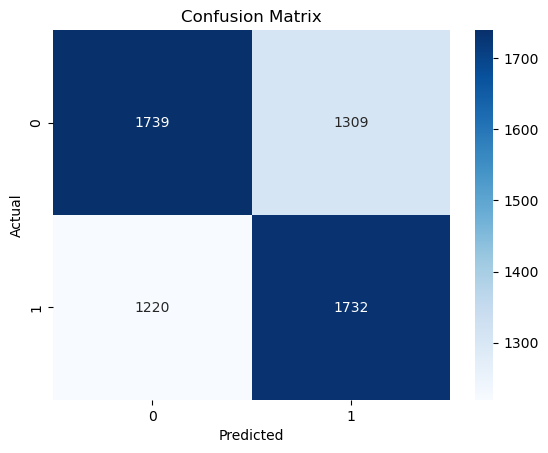

In [78]:
cm= confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [41]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(model_dt, X_train_preprocessed, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.93467742 0.94072581 0.92741935 0.93346774 0.94153226]
Precision scores: [0.97058824 0.9711659  0.97156197 0.96897275 0.96962131]
Recall scores: [0.96169858 0.96752706 0.95295587 0.9621149  0.97002498]
Mean Accuracy: 0.9355645161290322
Mean Precision: 0.9703820316616586
Mean Recall: 0.962864279766861


In [20]:
y_prob = model_dt.predict_proba(X_test_preprocessed)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

NameError: name 'X_test_preprocessed' is not defined

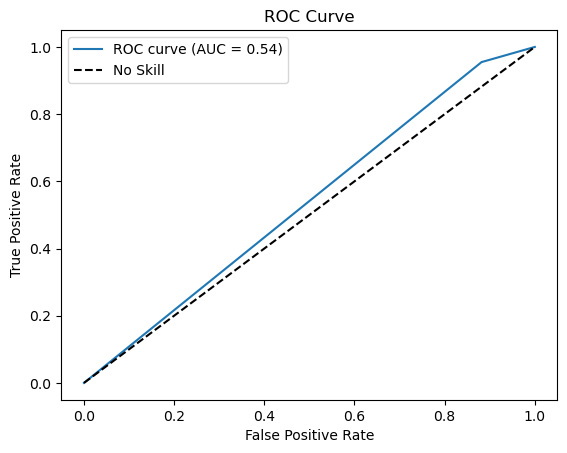

In [43]:
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Random FOrest

In [17]:
model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_train= model_rf.predict(X_train)
y_pred_test= model_rf.predict(X_test)

In [45]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))

Classification Report Train:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       390
           1       1.00      1.00      1.00     12010

    accuracy                           1.00     12400
   macro avg       1.00      1.00      1.00     12400
weighted avg       1.00      1.00      1.00     12400



In [18]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Test:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67      3048
           1       0.66      0.66      0.66      2952

    accuracy                           0.66      6000
   macro avg       0.66      0.66      0.66      6000
weighted avg       0.66      0.66      0.66      6000



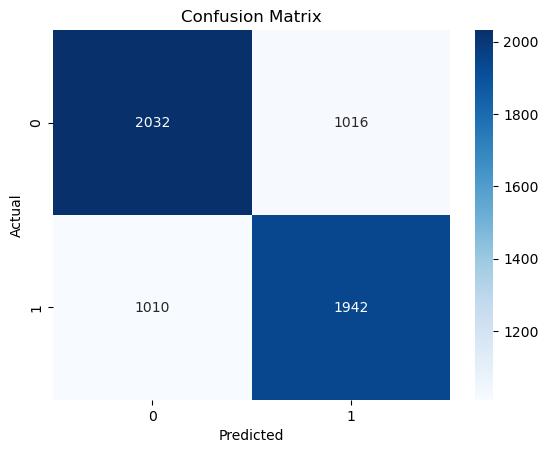

In [19]:
cm= confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [20]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(model_rf, X_train, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.67083333 0.66208333 0.65395833 0.66520833 0.65229167]
Precision scores: [0.67364017 0.66094771 0.65888842 0.66891323 0.64907333]
Recall scores: [0.66804979 0.67136929 0.64439834 0.65919469 0.66874222]
Mean Accuracy: 0.660875
Mean Precision: 0.6622925703690443
Mean Recall: 0.6623508661330523


In [21]:
y_prob = model_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.7167314832597145


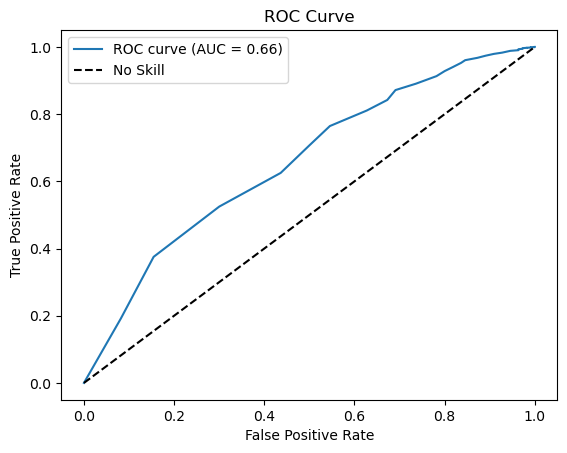

In [50]:
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 

from sklearn.linear_model import SGDClassifier


In [93]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=1.0)

# # Train and predict
model.fit(X_train_preprocessed, y_train)
y_pred_train= model.predict(X_train_preprocessed)
y_pred_test= model.predict(X_test_preprocessed)

In [94]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(model, X_train_preprocessed, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.69729167 0.68291667 0.67208333 0.690625   0.678125  ]
Precision scores: [0.69040987 0.67817014 0.67272727 0.68644068 0.670347  ]
Recall scores: [0.71991701 0.70124481 0.67551867 0.70610212 0.70568701]
Mean Accuracy: 0.6842083333333334
Mean Precision: 0.6796189933986154
Mean Recall: 0.7016939244086404


In [96]:
y_prob = model.predict_proba(X_test_preprocessed)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

AttributeError: This 'SVC' has no attribute 'predict_proba'